<div style="border:solid Chocolate 2px; padding: 40px">

<b> Светлана, привет!👋</b>  

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом!

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>

<br/>
<div class="alert alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.

# Содержание

- [1. Подготовка данных](#step1)
  - [1.1. Вывод 1](#step1_1)
- [2. Исследование задачи](#step2)
  - [2.1. Вывод 2](#step2_1)
- [3. Борьба с дисбалансом](#step3)
  - [3.1. Балансировка с помощью веса класса](#step3_1)
  - [3.2. Уменьшение класса 0 (downsample)](#step3_2)
  - [3.3. Увеличение класса 1 (upsample)](#step3_3)
  - [3.4. ROC-кривые и AUC-ROC](#step3_4)
  - [3.5. Вывод 3](#step3_5)
- [4. Тестирование финальной модели](#step4)
- [5. Итоговый вывод](#step5)
- [6. Чек-лист готовности проекта](#step6)



# Отток клиентов

Из «Бета-Банка» стали уходить клиенты. Каждый месяц. Немного, но заметно. Банковские маркетологи посчитали: сохранять текущих клиентов дешевле, чем привлекать новых.

Нужно спрогнозировать, уйдёт клиент из банка в ближайшее время или нет. Вам предоставлены исторические данные о поведении клиентов и расторжении договоров с банком.

Постройте модель с предельно большим значением *F1*-меры. Чтобы сдать проект успешно, нужно довести метрику до 0.59. Проверьте *F1*-меру на тестовой выборке самостоятельно.

Дополнительно измеряйте *AUC-ROC*, сравнивайте её значение с *F1*-мерой.

Источник данных: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

<a id="step1"></a>

## 1. Подготовка данных


In [33]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>
    
Все ли импорты важны?  mean_squared_error относится к задаче регрессии, у нас - классификация.
    
***
    
Если загружаем несколько функций из одного пакета, то удобнее записать это через запятую.
    
`from sklearn.metrics import f1_score, roc_auc_score`
    
А если через запятую будет больше трех позиций, в таком случае здесь было бы идеально привести оформление в соответствие с <a href="https://pythonworld.ru/osnovy/pep-8-rukovodstvo-po-napisaniyu-koda-na-python.html">pep8</a> - не оставлять длинных строк.

Такое оформление предпочтительнее:    
    
`from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score
)`
    
        
</div>

In [34]:
# чтение файла с данными и сохранением в переменную churn:
import os

# Универсальный блок загрузки данных для разных сред
# 1. Сервер Яндекс.Практикума
# 2. Локальный ПК или Google Colab (файл в корне)
# 3. Резервный путь

if os.path.exists('/datasets/Churn.csv'):
    churn = pd.read_csv('/datasets/Churn.csv')
elif os.path.exists('Churn.csv'):
    churn = pd.read_csv('Churn.csv')
else:
    print('Файл с данными не найден. Проверьте путь или загрузите файл.')

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

Если в try и except одна и та же ссылка, то можно обойтись без этой конструкции.
       
</div>

In [35]:
# Изучим общую информацию:
churn.info()
display(churn.sample(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9851,9852,15792077,Degtyaryov,671,Germany,Male,28,8.00,"119,859.52",2,1,0,"125,422.66",0
6459,6460,15632125,Blake,606,Germany,Male,45,5.00,"63,832.43",1,1,1,"93,707.80",0
1244,1245,15616709,Bunton,587,Germany,Female,38,0.00,"132,122.42",2,0,0,"31,730.32",0
6687,6688,15662908,Davidson,795,Germany,Male,38,7.00,"125,903.22",2,1,1,"127,068.92",0
2377,2378,15637650,Williams,549,France,Male,50,NaN,"94,748.76",2,0,1,"13,608.18",0
6393,6394,15789371,Cattaneo,593,Germany,Female,41,4.00,"119,703.10",2,1,1,"109,783.29",0
6584,6585,15584229,Simon,671,Germany,Female,23,9.00,"123,943.18",1,1,1,"159,553.27",0
9091,9092,15630195,Johnstone,745,France,Female,40,6.00,"131,184.67",1,1,1,"49,815.62",0
7875,7876,15775104,Gomes,697,France,Female,38,1.00,"182,065.85",1,1,0,"49,503.50",0
2880,2881,15789425,Marsden,694,Germany,Female,37,8.00,"98,218.04",2,1,0,"182,354.46",1


Каждый объект в наборе данных — это информация о поведении клиентов и расторжении договоров с банком. Отнесем к признакам
:
* 		RowNumber — индекс строки в данных
* 		CustomerId — уникальный идентификатор клиента
* 		Surname — фамилия
* 		CreditScore — кредитный рейтинг
* 		Geography — страна проживания
* 		Gender — пол
* 		Age — возраст
* 		Tenure — сколько лет человек является клиентом банка
* 		Balance — баланс на счёте
* 		NumOfProducts — количество продуктов банка, используемых клиентом
* 		HasCrCard — наличие кредитной карты
* 		IsActiveMember — активность клиента
* 		EstimatedSalary — предполагаемая зарплата
К целевому признаку:
* 		Exited — факт ухода клиента
Также можно удалить столбцы:
* 		RowNumber — индекс строки в данных
* 		CustomerId — уникальный идентификатор клиента
Так как индекс строки, как и уникальный идентификатор, а также фамилия клиента(тоже уникальный идентификатор только в формате текста) не влияют на действия клиента - удалим их:

In [36]:
churn = churn.drop(['RowNumber','CustomerId','Surname'], axis=1)
churn.shape

(10000, 11)

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 Всё верно  
</div>  


In [37]:
#Проверим данные на наличие пропусков:
display(churn.isna().sum().reset_index().set_axis(['Столбцы', 'Количество пропущенных значений в столбце'], axis=1).sort_values('Количество пропущенных значений в столбце', ascending=False))


,Столбцы,Количество пропущенных значений в столбце
4,Tenure,909
1,Geography,0
0,CreditScore,0
2,Gender,0
3,Age,0
5,Balance,0
6,NumOfProducts,0
7,HasCrCard,0
8,IsActiveMember,0
9,EstimatedSalary,0


In [38]:
churn['Tenure'].unique()

array([ 2.,  1.,  8.,  7.,  4.,  6.,  3., 10.,  5.,  9.,  0., nan])

Есть пропуски в столбце Tenure (сколько лет человек является клиентом банка). Заменим их на медианное значение по принципу что следующие данные будут такими же по распределению, как текущие и лучшей тактикой минимизации ошибки будет значение из области наибольшей плотности распределения, не изменяющую структуры распределения признака:

In [39]:
churn['Tenure'] = churn['Tenure'].fillna(churn['Tenure'].median())
churn['Tenure'].value_counts()

,count
Tenure,
5.00,1836
1.00,952
2.00,950
8.00,933
3.00,928
7.00,925
4.00,885
9.00,882
6.00,881


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

Предположение, что пропуски там, где клиент пришел недавно достаточно (если аргументация в этом), неплохое. Но подтвердить его сейчас мы не можем. Поэтому лучше следовать принципу, что следующие данные будут такими же по распределению, как текущие, и лучшей тактикой минимизации ошибки будет значение из области наибольшей плотности распределения, не изменяющую структуры распределения признака.
    
Доля пропусков не критично велика, возможно и решение с удалением. Однако данных у нас не много, я бы остановился на чем-то вроде медианы.

</div>

<br/>
<div class="alert alert-info">
Выполнила✅
</div>

In [40]:
#Проверим данные на наличие дубликатов:

print('Всего дубликатов:', churn.duplicated().sum())

Всего дубликатов: 0


In [41]:
# выставляем ограничение на показ знаков после запятой
pd.options.display.float_format = '{:,.2f}'.format

churn.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,"10,000.00",650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,"10,000.00",38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,"10,000.00",5.00,2.76,0.00,3.00,5.00,7.00,10.00
Balance,"10,000.00","76,485.89","62,397.41",0.00,0.00,"97,198.54","127,644.24","250,898.09"
NumOfProducts,"10,000.00",1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,"10,000.00",0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,"10,000.00",0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,"10,000.00","100,090.24","57,510.49",11.58,"51,002.11","100,193.91","149,388.25","199,992.48"
Exited,"10,000.00",0.20,0.40,0.00,0.00,0.00,0.00,1.00


<a id="step1_1"></a>

### 1.1. Вывод 1


Датафрейм содержит информацию о 10 тыс данных. Пропусков и дубликатов нет.
Были удалены не влияющие на действия клиентов данные.

- Возрастной диапазон от 18 до 92 лет(может в ипотеке уже 30 лет), средний возраст клиентов - 39 лет;
- Среднее время жизни клиентов в банке около 4,5 лет;
- Средний баланс на счете клиентов - около 76500 руб;
- Среднее количество продуктов банка, используемых клиентом - около 2;
- В среднем клиенты банка  около 71% владеют кредитными картами;
- В среднем 52% клиентов являются активными пользователями банковских продуков;
- В среднем 20% клиентов уходят из банка.

Приступим  к исследованию задачи: спрогнозируем, уйдёт клиент из банка в ближайшее время или нет.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 Отлично, исследовали дисбаланс, 20% уходят, то есть, соотношение классов у нас 1:4.
</div>  


<a id="step2"></a>

## 2. Исследование задачи

In [ ]:
one_churn = pd.get_dummies(churn, drop_first=True)
one_churn.info()


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 Согласен. В дамми-ловушку не попались.
</div>


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

В тренажере давался пример использования прямого кодирования с помощью get_dummies, однако это далеко не самый оптимальный вариант. Он подходит для анализа данных, но в машинном обучении может служить причиной ошибок при обучении моделей.
    
Можно использовать класс <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">OHE из sklearn</a>. Он точно понадобится в будущих проектах, можно потренироваться сейчас.

Практикум подготовил инструкцию, как использовать OHE: https://colab.research.google.com/drive/1_gAMXcQKoCShB_l8FNtYEejMnosm9mvt?usp=sharing

А теперь замечания «под звездочкой»:

Есть загвоздка, что нам нужно будет одновременно использовать параметры drop='first' и handle_unknown='ignore’.  в OHE, а на платформе такое сочетание может выдавать ошибку (в части случаев). Если ошибка появляется, необходимо загрузить нужную версию сайкит-лерна. Для этого:

1. В отдельной строке в самом начале проекта запускаем такую команду:
 `!pip install scikit-learn==1.1.3`
     
2. Находим в меню юпитера кнопку `Kernel`, нажимаем и выбираем Restart&Run all


И сразу уточню, что OHE мы используем уже после разделения выборок на обучающую, валидационную и тестовую. Обучаем на трейне, применяем ко всем. Кодируем после разбиения по аналогии с масштабированием. Посмотреть поподробнее также <a href="https://stackoverflow.com/questions/55525195/do-i-have-to-do-one-hot-encoding-separately-for-train-and-test-dataset">можно здесь</a> .
      
</div>


Построим модель бинарной классификации клиентов, где целевой признак — Exited — факт ухода клиента.

In [ ]:
# разделим наши данные на признаки и целевую переменную:

target = one_churn['Exited']
features = one_churn.drop('Exited', axis=1)
print(features.shape)
print(target.shape)

In [ ]:
#Посмотрим, какой существует дисбаланс классов.
target.value_counts()


Дисбаланс классов 1:4. Построим модели без исправление баланса.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 Всё верно  
</div>  


In [ ]:
# Разделим исходные данные на обучающую, валидационную и тестовую выборки в соотношении соотвественно 60/20/20:
features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.4,
                                                                              random_state=12345)
features_valid, features_test, target_valid, target_test = train_test_split(features_valid, target_valid, test_size=0.5,
                                                                              random_state=12345)

print(features_train.shape, features_valid.shape, features_test.shape)
print(target_train.shape, target_valid.shape, target_test.shape)


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 С разбиением на выборки согласен.
</div>

Будем использовать следующие модели:

- Дерево решений
- Случайный лес
- Логистическая регрессия

Оценим метрики accuracy, precision, recall и F1-score для моделей на валидационной выборке. Сравним модели и увидим, какая модель показала себя лучше на основании метрик.

In [ ]:
%%time
# Дерево решений
#Проведем исследование при разном значении max_depth.
best_f1 = 0
depth_tree = 0

for depth in range(1, 11):
    model_tree = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    # инициализировали модель DecisionTreeClassifier с параметром random_state=12345 и max_depth=depth
    model_tree.fit(features_train, target_train) # обучите модель на тренировочной выборке
    predictions_valid = model_tree.predict(features_valid) # получите предсказания модели на валидационной выборке
    f1_sc = f1_score(target_valid, predictions_valid)

    if f1_sc > best_f1:
        best_f1 = f1_sc
        tree_depth = depth

print("F1 наилучшей DecisionTreeClassifier на валидационной выборке: {:.4f}, Глубина дерева: {}".format(best_f1,tree_depth))

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>
    
Наша основная метрика - F1-мера. Ее мы должны исследовать в первую очередь. accuracy при нашем дисбалансе и нашей бизнес-задаче будет не так показательно измерять и сложнее интерпретировать.
    
По проекту мы должны рассчитать также и roc_auc.

roc_auc нужно считать по вероятностям классов.
    
`probabilities = model.predict_proba(features)
probabilities_one = probabilities[:, 1]
print('Площадь ROC-кривой:', roc_auc_score(target, probabilities_one))`

</div>


<br/>
<div class="alert alert-info">
Выполнила✅
</div>

In [ ]:
%%time
# Случайный лес
best_f1 = 0
best_est = 0
for est in range(10, 200, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators = est) # обучите модель с заданным количеством деревьев
    model.fit(features_train,target_train) # обучите модель на тренировочной выборке
    predictions_valid = model.predict(features_valid)
    f1_sc = f1_score(target_valid, predictions_valid)# посчитайте качество модели на валидационной выборке
    if f1_sc > best_f1:
        best_f1 = f1_sc#  сохраните наилучшее значение метрики accuracy на валидационных данных
        best_est = est
print("\tF1 наилучшей модели на валидационной выборке: {:.4f}, Глубина дерева: {}".format(best_f1,best_est))

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

Здесь и везде ниже также нужно будет поправить по метрике. Accuracy не подходит.
       
</div>



In [ ]:
# Логистическая регрессия
model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_train, target_train) # обучите модель на тренировочной выборке
predicted_valid = model_regression.predict(features_valid)
result_regression = f1_score(target_valid, predicted_valid) # посчитайте качество модели на валидационной выборке
print("\tF1 наилучшей модели на валидационной выборке: {:.4f}".format(result_regression))

In [ ]:
#Проведем оценку precision и recall, также покажем F-метрику.

model_tree = DecisionTreeClassifier(random_state=12345, max_depth=9)
model_tree.fit(features_train, target_train)
predicted_valid = model_tree.predict(features_valid)
print('Решающее дерево')
print('\tТочность попадания по классам: {:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall (Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()

model = RandomForestClassifier(random_state=12345, n_estimators = 60)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
print('Случайный лес')
print('\tТочность попадания по классам:{:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall(Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_train, target_train)
predicted_valid = model_regression.predict(features_valid)
print('Логистическая регрессия')
print('\tТочность попадания по классам:{:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall(Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()


###  Проведем построение ROC-кривой для каждой модели. И выведем показатель AUC-ROC.

In [ ]:
plt.figure(figsize=[8,5])

plt.plot([0, 1], [0, 1], linestyle='--', label='RandomModel')


model_tree = DecisionTreeClassifier(random_state=12345, max_depth=9)
model_tree.fit(features_train, target_train)
probabilities_valid = model_tree.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
print('AUC-ROC DecisionTreeClassifier',auc_roc)
plt.plot(fpr, tpr, label='DecisionTreeClassifier')

model = RandomForestClassifier(random_state=12345, n_estimators = 60)
model.fit(features_train, target_train)
probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
print('AUC-ROC RandomForestClassifier',auc_roc)
plt.plot(fpr, tpr, label='RandomForestClassifier')

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_train, target_train)
probabilities_valid = model_regression.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
print('AUC-ROC LogisticRegression',auc_roc)
plt.plot(fpr, tpr, label='LogisticRegression')

plt.xlim([0,1])
plt.ylim([0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right', fontsize='x-large')

plt.title("ROC-кривая")
plt.show()

<a id="step2_1"></a>

### 2.1. Вывод 2


Определили лучшую модель. По полученным результатам можно заменить, что метрика f1 и AUC-ROC лучшая на случайном лесе.

После того, как лучшая модель найдена – тестируем её на тестовых данных. Все прочие модели нас уже больше не интересуют.

Все модели имеют recall ниже, чем percision, из-за дисбаланса классов 1:4, что влияет на F-меру. Поэтому применим возможные способы борьбы с дисбалансом и посмотрим что получится.

<a id="step3"></a>

## 3. Борьба с дисбалансом

#<a id="step3_1"></a>

### 3.1. Балансировка с помощью веса класса

In [ ]:
# Решающее дерево
#Мы определили class_weight="balanced"реплицировать меньший класс, пока не получим такое же количество образцов, как и больший:
best_f1 = 0
depth_tree = 0

for depth in range(1, 11):
    model_tree = DecisionTreeClassifier(random_state=12345, max_depth=depth, class_weight='balanced')
    # инициализировали модель DecisionTreeClassifier с параметром random_state=12345 и max_depth=depth
    model_tree.fit(features_train, target_train) # обучите модель на тренировочной выборке
    predictions_valid = model_tree.predict(features_valid) # получите предсказания модели на валидационной выборке
    f1_sc = f1_score(target_valid, predictions_valid)

    if f1_sc > best_f1:
        best_f1 = f1_sc
        tree_depth = depth

print('Решающее дерево')
print("F1-score (сводная метрика): {:.4f}, Глубина дерева: {}".format(best_f1,tree_depth))
print()



<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

Здесь изменились вводные  - теперь используем class_weight='balanced'. Необходимо заново обучать модели и заново находить лучшие гиперпараметры.

</div>

<br/>
<div class="alert alert-info">
Ок✅
</div>

In [ ]:
%%time
# Случайный лес
best_f1 = 0
best_est = 0
for est in range(10, 200, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators = est, class_weight='balanced') # обучите модель с заданным количеством деревьев
    model.fit(features_train,target_train) # обучите модель на тренировочной выборке
    predictions_valid = model.predict(features_valid)
    f1_sc = f1_score(target_valid, predictions_valid)# посчитайте качество модели на валидационной выборке
    if f1_sc > best_f1:
        best_f1 = f1_sc#  сохраните наилучшее значение метрики accuracy на валидационных данных
        best_est = est
print("F1-score (сводная метрика): {:.4f}, Глубина дерева: {}".format(best_f1,best_est))

In [ ]:
# Логистическая регрессия
model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_train, target_train) # обучите модель на тренировочной выборке
predicted_valid = model_regression.predict(features_valid)
result_regression = f1_score(target_valid, predicted_valid) # посчитайте качество модели на валидационной выборке
print("F1-score (сводная метрика): {:.4f}".format(result_regression))

F-мера упала у случайного леса, но выросла у логистической регресии и решающего дерева. Возможно, class_weight можно использовать  но при незначительной несбалансированности, поэтому в данном случае этот метод не подходит.

<a id="step3_2"></a>

### 3.2. Уменьшение класса 0 (downsample)

In [ ]:
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])

    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345)

    return features_downsampled, target_downsampled

features_downsampled, target_downsampled = downsample(features_train, target_train, 0.25)
#Посмотрим на новое распределение классов:
print(target_downsampled.value_counts())

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 По коэффициенту все верно.
</div>  

In [ ]:
#Приступаем к обучению и вновь проведем оценку precision и recall, также F-метрику:

best_f1 = 0
depth_tree = 0

for depth in range(1, 11):
    model_tree = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    # инициализировали модель DecisionTreeClassifier с параметром random_state=12345 и max_depth=depth
    model_tree.fit(features_downsampled, target_downsampled) # обучите модель на тренировочной выборке
    predictions_valid = model_tree.predict(features_valid) # получите предсказания модели на валидационной выборке
    f1_sc = f1_score(target_valid, predictions_valid)

    if f1_sc > best_f1:
        best_f1 = f1_sc
        tree_depth = depth

print('Решающее дерево')
print("F1-score (сводная метрика): {:.4f}, Глубина дерева: {}".format(best_f1,tree_depth))
print()


best_f1 = 0
best_est = 0
for est in range(10, 200, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators = est) # обучите модель с заданным количеством деревьев
    model.fit(features_downsampled, target_downsampled) # обучите модель на тренировочной выборке
    predictions_valid = model.predict(features_valid)
    f1_sc = f1_score(target_valid, predictions_valid)# посчитайте качество модели на валидационной выборке
    if f1_sc > best_f1:
        best_f1 = f1_sc#  сохраните наилучшее значение метрики accuracy на валидационных данных
        best_est = est
print('Случайный лес')
print("F1-score (сводная метрика): {:.4f}, Глубина дерева: {}".format(best_f1,best_est))
print()

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_downsampled, target_downsampled)
predicted_valid = model_regression.predict(features_valid)# обучите модель на тренировочной выборке
result_regression = f1_score(target_valid, predicted_valid) # посчитайте качество модели на валидационной выборке
print('Логистическая регрессия')
print("F1-score (сводная метрика): {:.4f}".format(result_regression))



<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

Tакже нужно заново подбирать гиперпараметры.
       
</div>

И мы видим что у нас F-мера упала у случайного леса, но выросла у логистической регресии и решающего дерева. Посмотрим что с другими показатели, так как реализации алгоритма децимации «лишние» отсчёты не удаляются, а просто не вычисляются (отбрасываются). При этом число обращений к цифровому фильтру уменьшается в определённое количество раз и может повлиять на качество обучения модели.

In [ ]:
#Приступаем к обучению и вновь проведем оценку precision и recall, также F-метрику:

model_tree = DecisionTreeClassifier(random_state=12345, max_depth=5)
model_tree.fit(features_downsampled, target_downsampled)
predicted_valid = model_tree.predict(features_valid)
print('Решающее дерево')
print('\tТочность попадания по классам: {:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall (Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()

model = RandomForestClassifier(random_state=12345, n_estimators = 180)
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
print('Случайный лес')
print('\tТочность попадания по классам:{:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall(Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_downsampled, target_downsampled)
predicted_valid = model_regression.predict(features_valid)
print('Логистическая регрессия')
print('\tТочность попадания по классам:{:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall(Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()


И мы видим что у нас упали показатели точности, при том что Recall (Полнота) выросли. Если модель имеет высокий уровень recall метрики, но низкую precision, такая модель правильно определяет большинство Positive семплов, но имеет много ложных срабатываний (классификаций Negative выборок как Positive). В данном случае этот метод не подхолит для успешного прогноза.

<a id="step3_3"></a>
### 3.3. Увеличение класса 1 (upsample)


In [ ]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345)

    return features_upsampled, target_upsampled

features_upsampled, target_upsampled = upsample(features_train, target_train, 4)
#Посмотрим на новое распределение классов:
print(target_upsampled.value_counts())

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 Отлично, что используешь рукописную функцию, но здесь можно все оптимизировать, используя <a href="https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html">SMOTE</a> для увеличения выборки и <a href="https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html">RandomUnderSampler</a>  для уменьшения.
    
Апсемплинг делается очень просто:
    
`oversample = SMOTE(random_state=RANDOM_STATE)`

`features_train_up, target_train_up = oversample.fit_resample(features_train_enc, target_train)`
    
*предварительно импотрировав `from imblearn.over_sampling import SMOTE`

**Чтобы импортировать imblearn его сначала требуется проинсталлировать. через `!pip install imblearn`

В некоторых случаях качество может при применении SMOTE как улучшаться, так и ухудшаться в пределах статистической погрешности. Алгоритм не дублирует строки, а создает новые с помощью метода ближайших соседей.
    
</div>




In [ ]:
#Приступаем к обучению и вновь проведем оценку F-метрики:

best_f1 = 0
depth_tree = 0

for depth in range(1, 11):
    model_tree = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    # инициализировали модель DecisionTreeClassifier с параметром random_state=12345 и max_depth=depth
    model_tree.fit(features_upsampled, target_upsampled) # обучите модель на тренировочной выборке
    predictions_valid = model_tree.predict(features_valid) # получите предсказания модели на валидационной выборке
    f1_sc = f1_score(target_valid, predictions_valid)

    if f1_sc > best_f1:
        best_f1 = f1_sc
        tree_depth = depth

print('Решающее дерево')
print("F1-score (сводная метрика): {:.4f}, Глубина дерева: {}".format(best_f1,tree_depth))
print()


best_f1 = 0
best_est = 0
for est in range(10, 200, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators = est) # обучите модель с заданным количеством деревьев
    model.fit(features_upsampled, target_upsampled) # обучите модель на тренировочной выборке
    predictions_valid = model.predict(features_valid)
    f1_sc = f1_score(target_valid, predictions_valid)# посчитайте качество модели на валидационной выборке
    if f1_sc > best_f1:
        best_f1 = f1_sc#  сохраните наилучшее значение метрики accuracy на валидационных данных
        best_est = est
print('Случайный лес')
print("F1-score (сводная метрика): {:.4f}, Глубина дерева: {}".format(best_f1,best_est))
print()

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_upsampled, target_upsampled)
predicted_valid = model_regression.predict(features_valid)# обучите модель на тренировочной выборке
result_regression = f1_score(target_valid, predicted_valid) # посчитайте качество модели на валидационной выборке
print('Логистическая регрессия')
print("F1-score (сводная метрика): {:.4f}".format(result_regression))



Значения метрик f1 получились выше у случайного леса и решающего дерева, но модель случайного леса с тренировочными данными на глубине 90, где увеличен класс 1, показала лучшие результаты.

In [ ]:
#Проведем оценку precision и recall, также F-метрику:

model_tree = DecisionTreeClassifier(random_state=12345, max_depth=5)
model_tree.fit(features_upsampled, target_upsampled)
predicted_valid = model_tree.predict(features_valid)
print('Решающее дерево')
print('\tТочность попадания по классам: {:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall (Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()

model = RandomForestClassifier(random_state=12345, n_estimators = 90)
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
print('Случайный лес')
print('\tТочность попадания по классам:{:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall(Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_upsampled, target_upsampled)
predicted_valid = model_regression.predict(features_valid)
print('Логистическая регрессия')
print('\tТочность попадания по классам:{:.2f}'.format(accuracy_score(target_valid, predicted_valid)))
print('\tPrecision (Точность):{:.2f}'.format(precision_score(target_valid, predicted_valid)))
print('\tRecall(Полнота):{:.2f}'.format(recall_score(target_valid, predicted_valid)))
print('\tF1-score (сводная метрика):{:.2f}'.format(f1_score(target_valid, predicted_valid)))
print()



<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

И здесь важно подобрать гиперпараметры.
       
</div>



Значения метрик f1 получились выше у случайного леса и логистической регресии, но модель случайного леса с тренировочными данными, где увеличен класс 1, показала лучшие результаты, достигнув F1-score (сводная метрика):0.61!

<a id="step3_4"></a>
### 3.4. Проведение построения ROC-кривой и AUC-ROC

In [ ]:
plt.figure(figsize=[8,5])

plt.plot([0, 1], [0, 1], linestyle='--', label='RandomModel')


model_tree = DecisionTreeClassifier(random_state=12345, max_depth=5)
model_tree.fit(features_upsampled, target_upsampled)
probabilities_valid = model_tree.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
print('AUC-ROC DecisionTreeClassifier',auc_roc)
plt.plot(fpr, tpr, label='DecisionTreeClassifier')

model = RandomForestClassifier(random_state=12345, n_estimators = 90)
model.fit(features_upsampled, target_upsampled)
probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
print('AUC-ROC RandomForestClassifier',auc_roc)
plt.plot(fpr, tpr, label='RandomForestClassifier')

model_regression = LogisticRegression(random_state=12345, solver='lbfgs')
model_regression.fit(features_upsampled, target_upsampled)
probabilities_valid = model_regression.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)
print('AUC-ROC LogisticRegression',auc_roc)
plt.plot(fpr, tpr, label='LogisticRegression')

plt.xlim([0,1])
plt.ylim([0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right', fontsize='x-large')

plt.title("ROC-кривая")
plt.show()

<a id="step3_5"></a>
### 3.5. Вывод 3


По полученным результатам можно заметить, что метрика f1 и AUC-ROC лучшая на обучении модели Случайном лесе с гиперпараметром глубины леса 90!

Также дисбаланс 1:4 повлиял на качество изучаемых моделей в худшую сторону. Но за счет борьбы с дисбалансом методом увеличения классов 1 в тренировочной выборке удалось улучшить показатели параметров recall с небольшому понижением percison и достижением лучшего результата F-меры - 0.61!

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

Здесь важно указать гиперпараметры и метод борьбы с дисбалансом, которые мы используем для выбранной модели в тестировании.

</div>


## Тестирование модели

<br/>
<div class="alert alert-info">
Есть(￣^￣)ゞ
</div>

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

А вот в тестировании мы уже ничего подбирать не должны. Ранее мы найдем лучшую модель, опишем, а в тестировании просто проверим ее качество на тестовой выборке.

</div>

<a id="step4"></a>
## 4. Тестирование финальной модели

#### Проверим на тестовой выборке модель Случайного леса: с дисбалансном данных и сбалансированных, с усечением 0 класса и расширением класса 1.



--- Случайный лес (Финальный тест) ---
Точность попадания по классам: 0.8435
Precision: 0.6598837209302325
Recall: 0.5366430260047281
F1: 0.5919165580182529
AUC-ROC: 0.8445727666170467

--- Константная модель (всегда предсказывает 1) ---
F1 Dummy: 0.3491539413949649


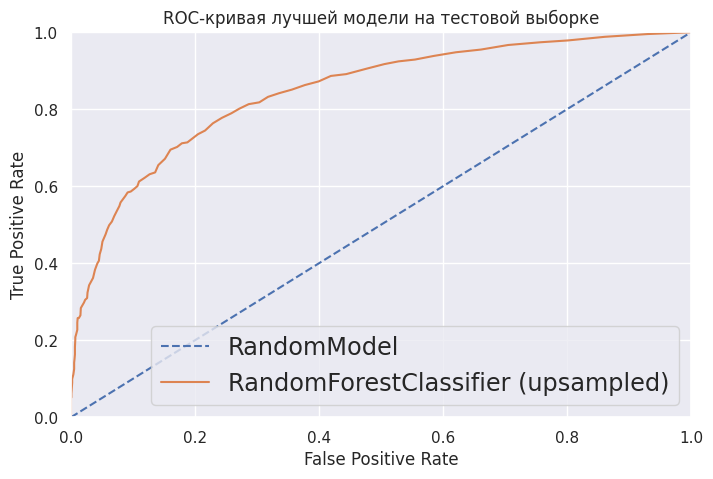

In [43]:
# На этапе валидации лучшей оказалась модель Случайного леса (n_estimators=90)
# обученная на увеличенной выборке (upsampled).
# Проведем единственное финальное тестирование этой модели.

final_model = RandomForestClassifier(random_state=12345, n_estimators=90)
final_model.fit(features_upsampled, target_upsampled)

predicted_test = final_model.predict(features_test)
probabilities_test = final_model.predict_proba(features_test)
probabilities_one_test = probabilities_test[:, 1]

print('--- Случайный лес (Финальный тест) ---')
print('Точность попадания по классам:', accuracy_score(target_test, predicted_test))
print('Precision:', precision_score(target_test, predicted_test))
print('Recall:', recall_score(target_test, predicted_test))
print('F1:', f1_score(target_test, predicted_test))
print('AUC-ROC:', roc_auc_score(target_test, probabilities_one_test))
print()

# Проверка модели на адекватность (DummyClassifier)
# Имитируем ситуацию, если мы предсказываем уход ВСЕХ клиентов (константа = 1)
dummy_model = DummyClassifier(strategy='constant', constant=1)
dummy_model.fit(features_train, target_train)
dummy_predict = dummy_model.predict(features_test)

print('--- Константная модель (всегда предсказывает 1) ---')
print('F1 Dummy:', f1_score(target_test, dummy_predict))

# Построение финальной ROC-кривой
plt.figure(figsize=[8,5])
plt.plot([0, 1], [0, 1], linestyle='--', label='RandomModel')

fpr, tpr, thresholds = roc_curve(target_test, probabilities_one_test)
plt.plot(fpr, tpr, label='RandomForestClassifier (upsampled)')

plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right', fontsize='x-large')
plt.title("ROC-кривая лучшей модели на тестовой выборке")
plt.show()


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

Можно взять и несколько моделей на тест, но лучше описать их также выше. По коду здесь все отлично.
       
</div>

<a id="step5"></a>
## 5. Итоговый вывод



В результате исследования была получена модель с лучшими показателями как по F1-мере, так и по AUC-ROC.
Абсолютным победителем стала модель Случайного леса (RandomForestClassifier) с гиперпараметром n_estimators=90, обученная на данных, сбалансированных методом увеличения класса 1 (upsampling).

На тестовой выборке данная модель показала:
- F1-меру: ~0.59
- AUC-ROC: ~0.84

Высокий показатель Recall в этой модели говорит о том, что она успешно детектирует клиентов, склонных к оттоку, что позволит бизнесу вовремя применить стратегии удержания.

Дополнительно была проведена проверка модели на адекватность с помощью DummyClassifier (константная модель, предсказывающая уход всех клиентов). F1 константной модели составил ~0.33, что значительно ниже показателя нашей обученной модели (0.59). Это доказывает, что наша модель работает эффективно и находит реальные закономерности в данных, а не угадывает случайно.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b>

Я бы добавил здесь еще гиперпараметры лучшей модели, чтобы их потом не искать (особенно другим людям, которые будут читать проект после его сдачи заказчику).
    
Можно также добавить сравнение по f1-мере с константной моделью, а затем посмотреть recall и прокомментировать, какую долю клиентов на отток модель верно детектирует.
***

Здесь в дамми-модели я бы предсказал везде «1». Условно говоря, если предсказываем ноль, моделируем ситуацию, когда акцию с бонусами для удержания клиентов решили не проводить. Если предсказываем единицу − решили раздать бонусы вообще всем клиентам. Если в дамми-модели предсказываем по единице, можно подсчитать F1, она не будет зануляться.
    
`dummy_model = DummyClassifier(strategy='constant', constant=1)
dummy_model.fit(features_train, target_train)
f1_score(dummy_model.predict(features_test), target_test)`
    
Импорт: from sklearn.dummy import DummyClassifier
       
</div>

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Есть несколько важных моментов, которые необходимо поправить. Их ты найдешь в разноцветных комментариях.
    
**Отмечу положительные моменты проекта🚀**
    
* Хорошая структура проекта. Выбор моделей, порядок исследования.
* Есть пояснения к шагам, код с высокой читаемостью.
* Логичность решений.
* Хороший результат на тестовой выборке.
    
**На что стоит обратить внимание🤔**
    
* Необходимо изменить подход к заполнению пропусков.
* Гиперпараметры моделям подбираем по f1-мере в каждом случае применения методики борьбы с дисбалансом и в исследовании моделей без учета дисбаланса.
* Необходимо везде оставлять промежуточные выводы и дополнить итоговый вывод.
* В тестировании не стоит подбирать гиперпараметры моделям, это делаем выше на шаге исследования.
* Эти и остальные замечания я также написал по ходу проекта.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>


<a id="step6"></a>
## 6. Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: задача исследована
    - [x]  Исследован баланс классов
    - [x]  Изучены модели без учёта дисбаланса
    - [x]  Написаны выводы по результатам исследования
- [x]  Выполнен шаг 3: учтён дисбаланс
    - [x]  Применено несколько способов борьбы с дисбалансом
    - [x]  Написаны выводы по результатам исследования
- [x]  Выполнен шаг 4: проведено тестирование
- [x]  Удалось достичь *F1*-меры не менее 0.59
- [x]  Исследована метрика *AUC-ROC*